In [10]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import pandas as pd
from skimage import data
from skimage import img_as_ubyte

In [11]:
img = cv2.imread('child.png', cv2.IMREAD_GRAYSCALE)
flat = img.flatten()


hist, bins = np.histogram(flat, bins=256, range=[0, 256])
r_k = np.arange(256)
n_k = hist
total_pixels = img.size


p_rk = n_k / total_pixels


cdf = np.cumsum(p_rk)


L = 256
s_k = np.round((L - 1) * cdf).astype(np.uint8)


equalized_img = s_k[img]

In [12]:
df = pd.DataFrame({
    "r_k (Gray Level)": r_k,
    "n_k (Pixel Count)": n_k,
    "p(r_k)": p_rk,
    "CDF(r_k)": cdf,
    "s_k (Mapped Level)": s_k
})
df.head(20)

,r_k (Gray Level),n_k (Pixel Count),p(r_k),CDF(r_k),s_k (Mapped Level)
0,0,0,0.0,0.0,0
1,1,0,0.0,0.0,0
2,2,0,0.0,0.0,0
3,3,0,0.0,0.0,0
4,4,0,0.0,0.0,0
5,5,0,0.0,0.0,0
6,6,0,0.0,0.0,0
7,7,0,0.0,0.0,0
8,8,0,0.0,0.0,0
9,9,0,0.0,0.0,0


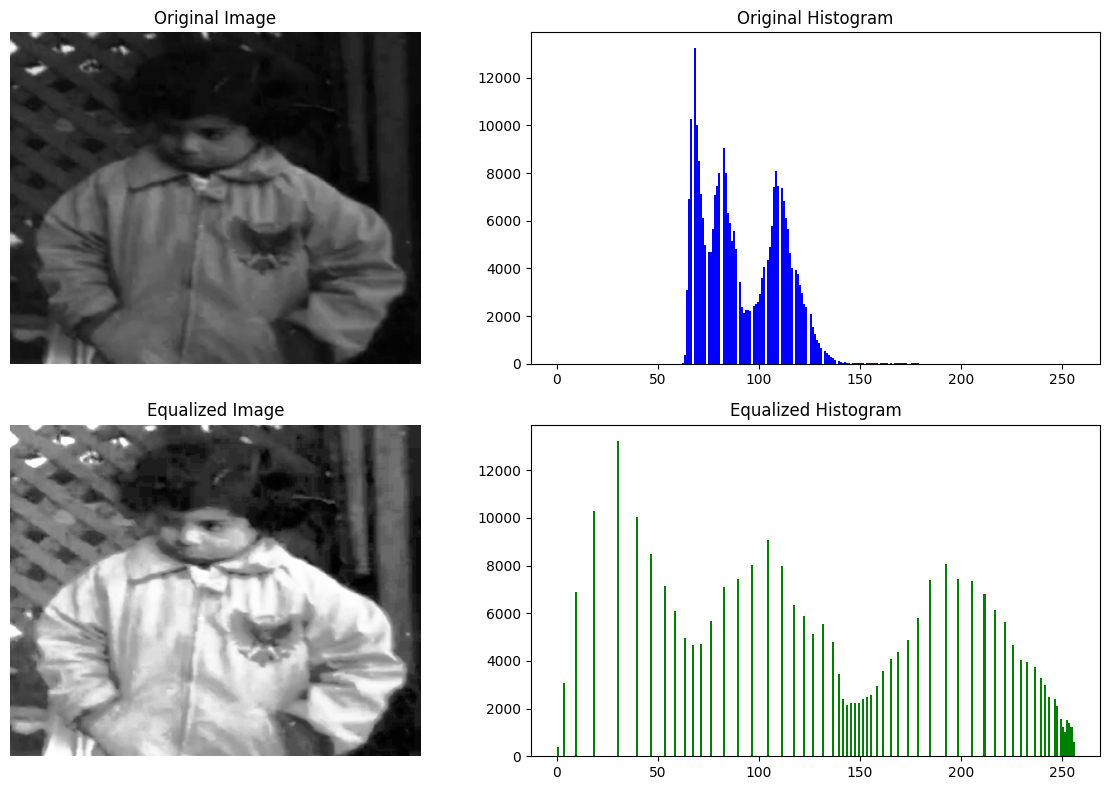

In [13]:
fig, axs = plt.subplots(2, 2, figsize=(12, 8))

axs[0, 0].imshow(img, cmap='gray')
axs[0, 0].set_title('Original Image')
axs[0, 0].axis('off')

axs[0, 1].hist(img.ravel(), bins=256, range=[0, 256], color='blue')
axs[0, 1].set_title('Original Histogram')

axs[1, 0].imshow(equalized_img, cmap='gray')
axs[1, 0].set_title('Equalized Image')
axs[1, 0].axis('off')

axs[1, 1].hist(equalized_img.ravel(), bins=256, range=[0, 256], color='green')
axs[1, 1].set_title('Equalized Histogram')

plt.tight_layout()
plt.show()